In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
import numpy as np

In [4]:
df["income_cat"]=pd.cut(df["median_income"], bins=[0, 1.5, 3.0, 4.5, 6.0, 7.5, np.inf], labels=[1,2,3,4,5,6])

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
for sett in (strat_train_set, strat_test_set):
    sett.drop(labels="income_cat", inplace=True, axis=1)

In [8]:
df =strat_train_set.copy()

In [9]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6895,-118.11,34.04,28.0,3913.0,696.0,2264.0,697.0,5.2446,258000.0,<1H OCEAN
2880,-118.97,35.38,35.0,1673.0,426.0,1041.0,413.0,1.3750,57500.0,INLAND
13769,-117.03,34.07,16.0,3784.0,577.0,1615.0,525.0,4.2333,220300.0,INLAND
18349,-122.17,37.43,24.0,3924.0,1142.0,7174.0,950.0,4.0972,387500.0,NEAR OCEAN
16188,-121.31,37.96,48.0,1112.0,227.0,583.0,216.0,2.3393,77600.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
10505,-117.72,33.43,5.0,1889.0,359.0,616.0,246.0,3.8992,500001.0,<1H OCEAN
19526,-120.97,37.65,16.0,3960.0,716.0,1776.0,724.0,3.9886,137500.0,INLAND
9347,-122.58,37.98,52.0,1180.0,216.0,467.0,197.0,4.9615,292200.0,NEAR BAY
3650,-118.44,34.21,37.0,1665.0,335.0,1011.0,343.0,4.8703,185100.0,<1H OCEAN


<Axes: xlabel='latitude', ylabel='longitude'>

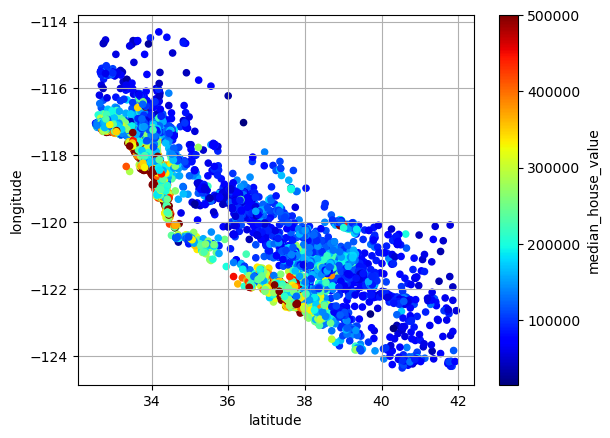

In [10]:
df.plot(kind="scatter", x="latitude", y="longitude", grid=True, cmap="jet", c="median_house_value")

In [13]:
df.drop(labels="ocean_proximity", inplace=True, axis=1)
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924528,-0.107785,0.047801,0.074600,0.106495,0.061007,-0.015011,-0.045270
latitude,-0.924528,1.000000,0.007503,-0.038804,-0.071162,-0.114462,-0.076343,-0.078346,-0.144204
housing_median_age,-0.107785,0.007503,1.000000,-0.364634,-0.324872,-0.299595,-0.306882,-0.115680,0.111570
total_rooms,0.047801,-0.038804,-0.364634,1.000000,0.928754,0.856439,0.917713,0.201676,0.135386
total_bedrooms,0.074600,-0.071162,-0.324872,0.928754,1.000000,0.876627,0.979970,-0.007201,0.048975
population,0.106495,-0.114462,-0.299595,0.856439,0.876627,1.000000,0.905145,0.007156,-0.024114
households,0.061007,-0.076343,-0.306882,0.917713,0.979970,0.905145,1.000000,0.013939,0.066012
median_income,-0.015011,-0.078346,-0.115680,0.201676,-0.007201,0.007156,0.013939,1.000000,0.685600
median_house_value,-0.045270,-0.144204,0.111570,0.135386,0.048975,-0.024114,0.066012,0.685600,1.000000


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

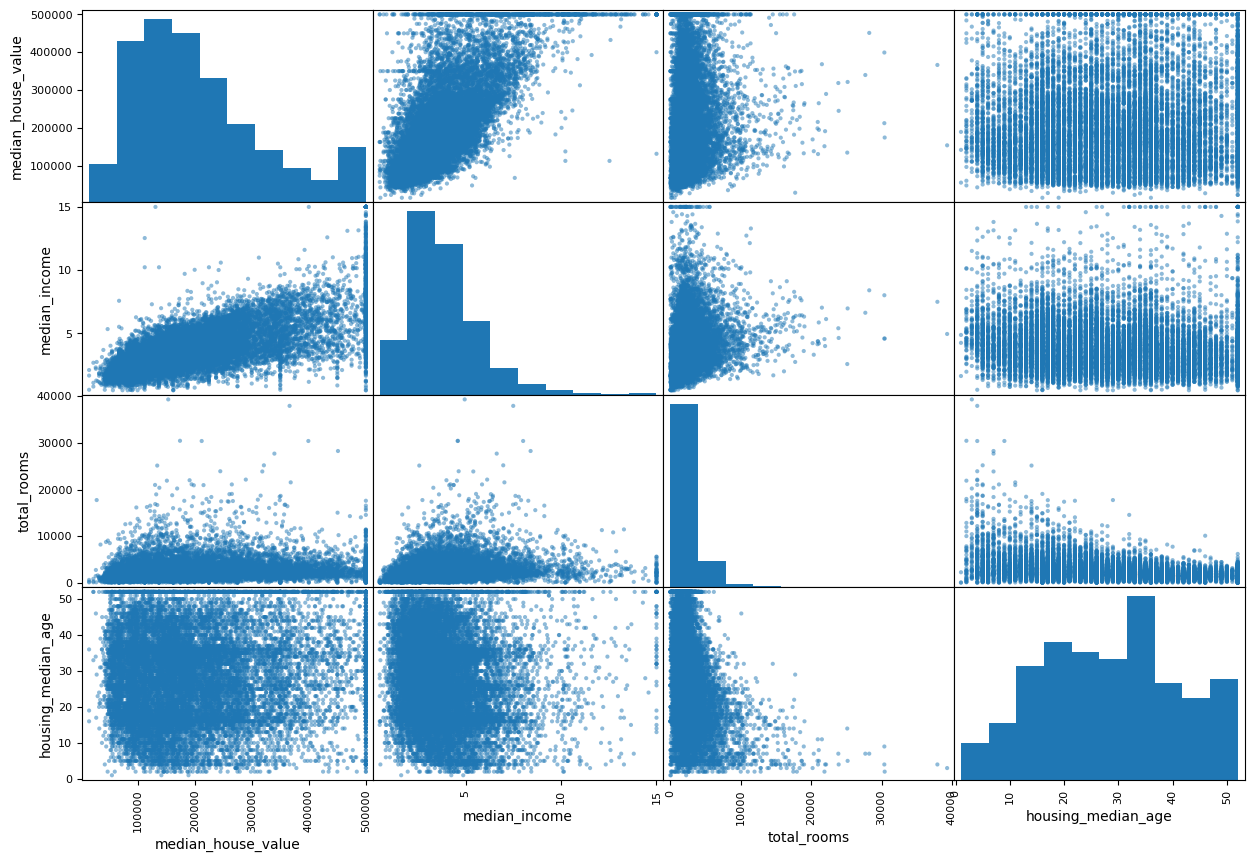

In [15]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(15, 10))

<Axes: xlabel='median_income', ylabel='median_house_value'>

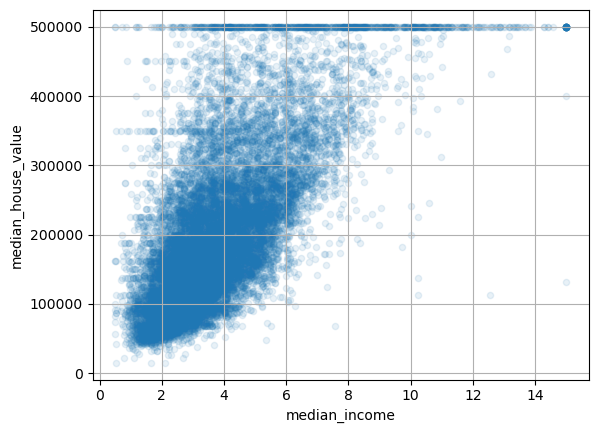

In [16]:
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)